# **Indego Data Analysis 🚴**

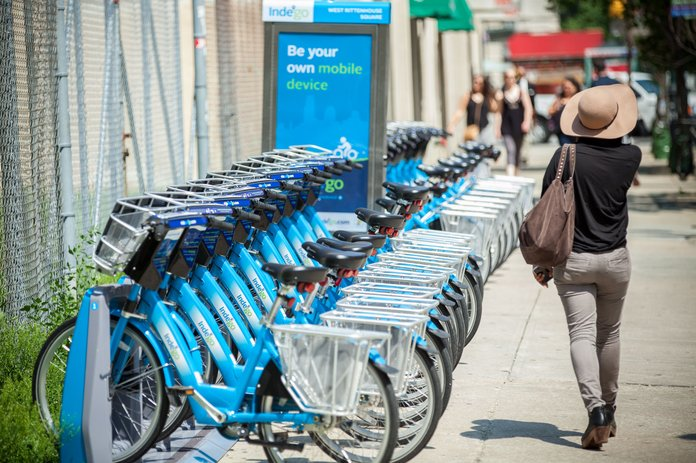

## **1. Import libraries 📚**

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

## **2. Load data ⬆️**

The selected dataset is in 2025 Q3.

The link taken: https://www.rideindego.com/about/data/

In [ ]:
df_indego = pd.read_csv('indego-trips-2025-q3.csv')

/tmp/ipython-input-2901425614.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_indego = pd.read_csv('indego-trips-2025-q3.csv')


## **3. Data Libraries 🗃️**

| **Feature**        | **Description**                                                                                                          |
|--------------------------|--------------------------------------------------------------------------------------------------------------------------|
| `trip_id`               | Locally unique integer that identifies the trip.                                                                        |
| `duration`              | Length of trip in minutes.                                                                                              |
| `start_time`            | The date/time when the trip began, presented in ISO 8601 format in local time.                                          |
| `end_time`              | The date/time when the trip ended, presented in ISO 8601 format in local time.                                          |
| `start_station`         | The station ID where the trip originated (for station name and more information, see the Station Table).                |
| `start_lat`             | The latitude of the station where the trip originated.                                                                  |
| `start_lon`             | The longitude of the station where the trip originated.                                                                 |
| `end_station`           | The station ID where the trip terminated (for station name and more information, see the Station Table).                |
| `end_lat`               | The latitude of the station where the trip terminated.                                                                  |
| `end_lon`               | The longitude of the station where the trip terminated.                                                                 |
| `bike_id`               | Locally unique integer that identifies the bike.                                                                       |
| `plan_duration`         | The number of days that the plan the passholder is using entitles them to ride; 0 is used for a single-ride plan (Walk-up). |
| `trip_route_category`   | “Round Trip” for trips starting and ending at the same station or “One Way” for all other trips.                        |
| `passholder_type`       | The name of the passholder’s plan.                                                                                      |
| `bike_type`             | The kind of bike used on the trip, including standard pedal-powered bikes or electric assist bikes.                     |


## **4. Data profiling 🪄**

### 4.1 Look at 5 random rows

In [ ]:
df_indego.sample(5)

,trip_id,duration,start_time,end_time,start_station,start_lat,start_lon,end_station,end_lat,end_lon,bike_id,plan_duration,trip_route_category,passholder_type,bike_type
125344,1216249431,12,7/28/2025 14:29,7/28/2025 14:41,3063,39.946331,-75.169800,3020,39.948551,-75.190071,11598,365.0,One Way,Indego365,standard
20745,1205327433,2,7/5/2025 20:43,7/5/2025 20:45,3237,39.917171,-75.170959,3197,39.920830,-75.170326,11938,30.0,One Way,Indego30,standard
73979,1210893695,9,7/17/2025 18:02,7/17/2025 18:11,3029,39.953800,-75.194794,3032,39.945271,-75.179710,13102,365.0,One Way,Indego365,standard
103302,1213820107,3,7/23/2025 18:14,7/23/2025 18:17,3161,39.954861,-75.180908,3321,39.954849,-75.172981,31455,30.0,One Way,Indego30,electric
142695,1218175042,42,8/1/2025 8:39,8/1/2025 9:21,3263,39.958599,-75.208099,3411,39.966930,-75.233589,3372.0,30.0,One Way,Indego30,standard


### 4.2 Data Types and Fundamental Information

In [ ]:
df_indego.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142997 entries, 0 to 142996
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   trip_id              142997 non-null  int64  
 1   duration             142997 non-null  int64  
 2   start_time           142997 non-null  object 
 3   end_time             142997 non-null  object 
 4   start_station        142997 non-null  int64  
 5   start_lat            142990 non-null  float64
 6   start_lon            142990 non-null  float64
 7   end_station          142997 non-null  int64  
 8   end_lat              140742 non-null  float64
 9   end_lon              140741 non-null  float64
 10  bike_id              142996 non-null  object 
 11  plan_duration        142996 non-null  float64
 12  trip_route_category  142996 non-null  object 
 13  passholder_type      142996 non-null  object 
 14  bike_type            142996 non-null  object 
dtypes: float64(5), in

### 4.3 Data Descriptions

In [ ]:
df_indego.describe()

,trip_id,duration,start_station,start_lat,start_lon,end_station,end_lat,end_lon,plan_duration
count,1.429970e+05,142997.000000,142997.000000,142990.000000,142990.000000,142997.000000,140742.000000,140741.000000,142996.000000
mean,1.210647e+09,17.302048,3179.630601,39.951998,-75.168607,3178.147632,39.952020,-75.168466,140.791505
std,4.292666e+06,55.415551,128.846740,0.015516,0.018561,130.059037,0.015657,0.018628,161.489929
min,1.203074e+09,1.000000,3000.000000,39.889938,-75.245216,3000.000000,39.889938,-75.245216,1.000000
25%,1.207000e+09,6.000000,3057.000000,39.943321,-75.179604,3055.000000,39.943321,-75.179520,30.000000
50%,1.210722e+09,10.000000,3163.000000,39.951210,-75.167351,3163.000000,39.951210,-75.167351,30.000000
75%,1.214288e+09,17.000000,3299.000000,39.959999,-75.156792,3299.000000,39.959999,-75.156723,365.000000
max,1.220859e+09,1440.000000,3437.000000,40.028259,-75.101212,3437.000000,40.028259,-75.101212,365.000000


## **5. Data cleaning 🧹**

### 5.1 Checking N/A values

In [ ]:
df_indego.isna().sum().sort_values(ascending=False)

,0
end_lon,2256
end_lat,2255
start_lon,7
start_lat,7
bike_id,1
plan_duration,1
passholder_type,1
bike_type,1
trip_route_category,1
end_time,0


- There are many empty rows seen in `end_lat`, `end_lon`, `start_lon`, `start_lat` and `passholder_type`

#### 5.1.2 Fill values in column with empty rows

`end_lat`, `end_lon`, `start_lat`, `start_lon` columns:

In [ ]:
cols_filled = ['end_lat', 'end_lon', 'start_lat', 'start_lon']

for col in cols_filled:
  df_indego[col] = df_indego[col].fillna(df_indego[col].median())

`passholder_type` column:

In [ ]:
df_indego['passholder_type'] = df_indego['passholder_type'].fillna(df_indego['passholder_type'].mode()[0])

Check again:

In [ ]:
df_indego.isna().sum().sort_values(ascending=False)

,0
trip_route_category,1
bike_type,1
bike_id,1
plan_duration,1
trip_id,0
duration,0
start_time,0
start_lon,0
start_lat,0
start_station,0


### 5.2 Find duplicates

In [ ]:
duplicates = df_indego.duplicated().sum()

print(f'🔁 Number of dupliactes found: {duplicates}')

🔁 Number of dupliactes found: 0


### 5.3 Fix data types

#### 5.3.1 Transform date:

In [ ]:
df_indego[['start_time','end_time' ]].sample(5)

,start_time,end_time
4955,7/2/2025 14:32,7/2/2025 15:22
56231,7/14/2025 7:08,7/14/2025 7:39
74676,7/17/2025 19:45,7/17/2025 19:58
54247,7/13/2025 15:50,7/13/2025 15:56
132668,7/29/2025 20:23,7/29/2025 20:46


In [ ]:
cols_time = ['start_time', 'end_time']

for col in cols_time:
  df_indego[col] = pd.to_datetime(df_indego[col])

Check again:

In [ ]:
df_indego[['start_time','end_time' ]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142997 entries, 0 to 142996
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   start_time  142997 non-null  datetime64[ns]
 1   end_time    142997 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 2.2 MB


#### 5.3.2 Transform categories:

In [ ]:
for col in df_indego:
  if df_indego[col].dtype == 'object':
    df_indego[col] = df_indego[col].astype('category')

Check again

In [ ]:
df_indego.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142997 entries, 0 to 142996
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   trip_id              142997 non-null  int64         
 1   duration             142997 non-null  int64         
 2   start_time           142997 non-null  datetime64[ns]
 3   end_time             142997 non-null  datetime64[ns]
 4   start_station        142997 non-null  int64         
 5   start_lat            142997 non-null  float64       
 6   start_lon            142997 non-null  float64       
 7   end_station          142997 non-null  int64         
 8   end_lat              142997 non-null  float64       
 9   end_lon              142997 non-null  float64       
 10  bike_id              142996 non-null  category      
 11  plan_duration        142996 non-null  float64       
 12  trip_route_category  142996 non-null  category      
 13  passholder_typ

## **6. EDA (Exploratory Data Analysis) 🔬**

#### 6.1 .Bike Type distribution

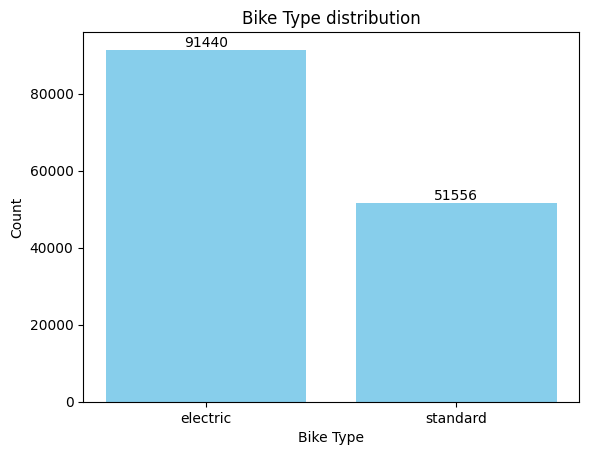

In [ ]:
values = df_indego['bike_type'].value_counts()
catgories = values.index

plt.bar(
    catgories,
    values,
    color='skyblue'
)

plt.title('Bike Type distribution')
plt.xlabel('Bike Type')
plt.ylabel('Count')

for i, v in enumerate(values):
    plt.text(i, v , v, ha='center', va='bottom')

plt.show()


- The electric bike is seen to be more favored by the majority of Indego customers. Nearly 300,000 trips are made by electric bike, and it is twice as many as standard.

- Indego customers are looking for quick, environmental and convenient solution to commute or travel from Indego's products

#### 6.2. Passholder counts

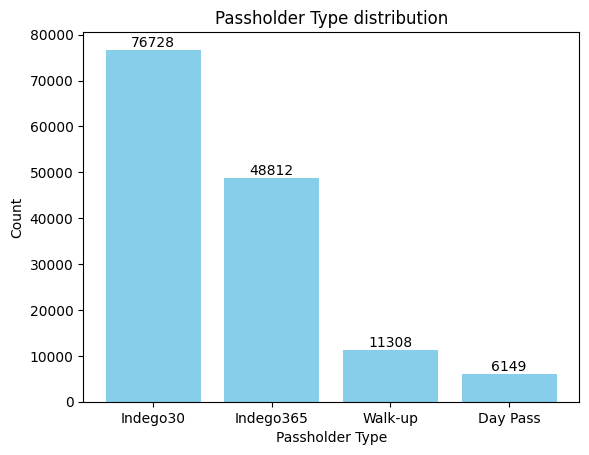

In [ ]:
values = df_indego['passholder_type'].value_counts()
catgories = values.index

plt.bar(
    catgories,
    values,
    color='skyblue'
)

plt.title('Passholder Type distribution')
plt.xlabel('Passholder Type')
plt.ylabel('Count')

for i, v in enumerate(values):
    plt.text(i, v + 5, v, ha='center', va='bottom')

plt.show()

-  Indego 30 days pass made up for the highest number of trip counts with 252,902 trips.

- Many customers are not daily users and tend to use short-term passes.

#### 6.3. Trip route counts

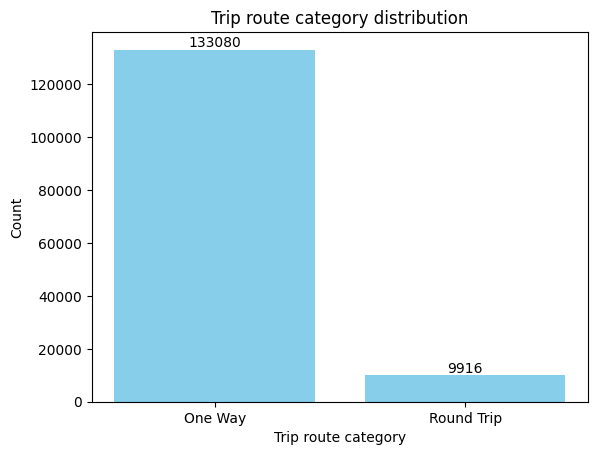

In [ ]:
values = df_indego['trip_route_category'].value_counts()
categories = values.index

plt.bar(
    categories,
    values,
    color = 'skyblue'
)

plt.title('Trip route category distribution')
plt.xlabel('Trip route category')
plt.ylabel('Count')

for i, v in enumerate(values):
  plt.text(i, v+5, v, ha='center', va='bottom')

plt.show()

- More than 400,000 trips are "One Way" and only less than 31,000 trips are "Round Trip"

- This can signify the flexibility and convenience of Indego that attracts many customers. But look into deeper then we see people tend to travel with planned destination.

#### 6.4. Bike Type through months

/tmp/ipython-input-2244859312.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('bike_type')
/tmp/ipython-input-2244859312.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


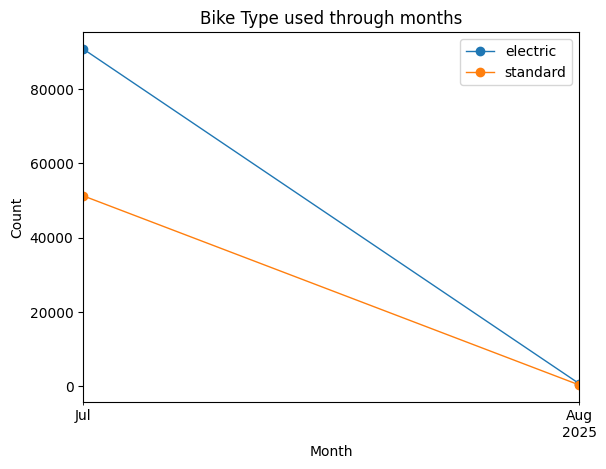

In [ ]:
monthly = (
    df_indego
    .set_index('start_time')
    .groupby('bike_type')
    .resample('M')
    .size()
    .unstack(0)
)

monthly.plot(
    linewidth=1,
    marker='o',
)

plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Bike Type used through months')
plt.legend()

plt.show()

- Through months, electric and standard bike both visibly increase from Agust to September.

- Electric bike have soared from about 90,000 to nearly 110,000. Standard bike observed to have the least growth from more than 50,000 to almost 60,000.

#### 6.5. Passholder through months

/tmp/ipython-input-781583598.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('passholder_type')
/tmp/ipython-input-781583598.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


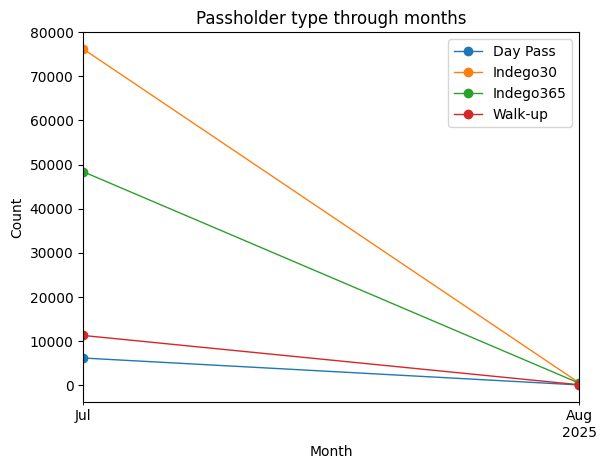

In [ ]:
monthly = (
    df_indego
    .set_index('start_time')
    .groupby('passholder_type')
    .resample('M')
    .size()
    .unstack(0)
)

monthly.plot(
    linewidth = 1,
    marker = 'o',
)

plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Passholder type through months')
plt.legend()

plt.show()

- Both Walk-Up and Day-Pass saw the decrease from August to Sepetember. they only reached underneath 20,000 through three months.

- On the contrary, Indego 30 and 365 have upsurged their numbers of pass registration since August. Especially, Indego 30 showed the most remarkable increase in registration in September with nearly 90,000 uses.

#### 6.6. Trip route through months

/tmp/ipython-input-2478988538.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('trip_route_category')
/tmp/ipython-input-2478988538.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


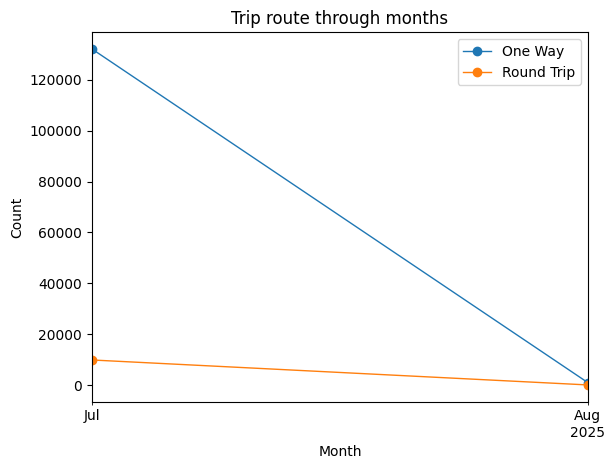

In [ ]:
monthly = (
    df_indego
    .set_index('start_time')
    .groupby('trip_route_category')
    .resample('M')
    .size()
    .unstack(0)
)

monthly.plot(
    linewidth = 1,
    marker = 'o'
)

plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Trip route through months')
plt.legend()

plt.show()

- One Way trips rises upto almost 160,000 trips. Round trip is the least favourable and steadily declining from August

#### 6.7. Trips through months

/tmp/ipython-input-404108768.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  trip_counts = df_indego.resample('M', on='start_time')['trip_id'].count()


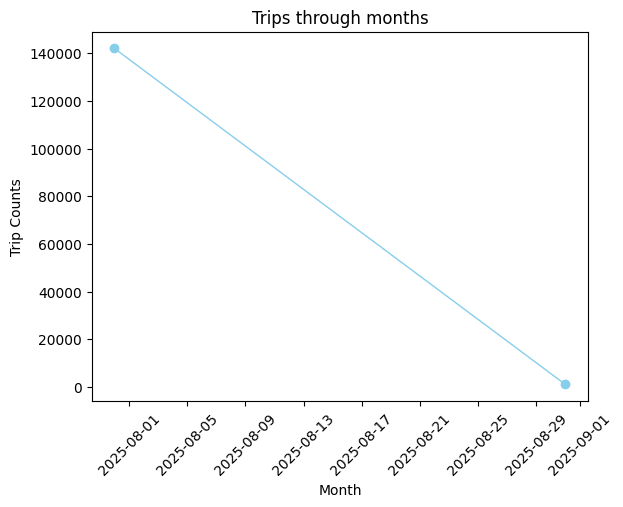

In [ ]:
trip_counts = df_indego.resample('M', on='start_time')['trip_id'].count()

plt.plot(
    trip_counts.index,
    trip_counts.values,
    color = 'skyblue',
    marker = 'o',
    linewidth = 1
)

plt.xlabel('Month')
plt.ylabel('Trip Counts')
plt.title('Trips through months')

plt.xticks(rotation=45)

plt.show()

- Number of trips are showing positive growth through time and peaked at more than 165,000 on Octorber 1st.

#### 6.8. Average Duration by bike type

In [ ]:
avg_dur_by_bike_type = df_indego.groupby('bike_type')['duration'].mean()

avg_dur_by_bike_type

/tmp/ipython-input-1615557199.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_dur_by_bike_type = df_indego.groupby('bike_type')['duration'].mean()


,duration
bike_type,
electric,16.924923
standard,17.971138


- Average duration of bike type covered is 16.81 minutes and standard is 18.18 mintues.

- This explains e-bike reach to the final destination quicker than standard one, which also showes one the main reason people would rather ride on e-bike than regular bike.

#### 6.9. Average Duration by route trip

In [ ]:
avg_dur_by_trip_route_category = df_indego.groupby('trip_route_category')['duration'].mean()

avg_dur_by_trip_route_category

/tmp/ipython-input-3860641685.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_dur_by_trip_route_category = df_indego.groupby('trip_route_category')['duration'].mean()


,duration
trip_route_category,
One Way,16.341441
Round Trip,30.195240


- Usually round trip is for people or tourist want to explore in the Philly city and visit attractions.

- That's why it takes longer time (28.28 minutes) to complete one trip comparing to one way (16.52 minutes) which is more pratical and straightforward to one destination.

#### 6.10. Average Duration by pass holder

In [ ]:
avg_dur_by_passholder_type = df_indego.groupby('passholder_type')['duration'].mean()

avg_dur_by_passholder_type

/tmp/ipython-input-713783616.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_dur_by_passholder_type = df_indego.groupby('passholder_type')['duration'].mean()


,duration
passholder_type,
Day Pass,41.298260
Indego30,15.803045
Indego365,12.061092
Walk-up,37.047754


- According to the average duration, long-term pass (Indego30, Indego365) accounts for the least duration covered with an average of 12 minutes and 16 minutes

- On the other hand, Day Pass and Walk-up has average duration of more than 30 minutes.

## **7 Final Conclusion ✅**

7.1. How would you recommend that decision makers quantify the current and recent growth
rate of the program?

- The dataset includes some interesting columns like pass holder, duration and type of bike information which can be used further as explanatory variables. Besides, location records are also imperative to identify the volumes of customer in each area.

- What is missing to navigate all of these variable effects on Idego's sharing bike business is revenue or a profit conversion. This can help explain futher potential of each factors that the board will not foresee thanks to more advanced data analysis.

7.2. Is there any evidence to suggest the program is growing either too slowly or too quickly?

- From observation, the trips made through months have increased from below 140,000 to with nearly 170,000 rides. In the period from Agust to September, it greaet skyrocketed to more than 15,000 rides, but from September to Octoer the growth has slowed down to around 10,000 rides

- According to the exploratory data analysis, the growth of Indego 30 and Indego 365 has soared more 10,000 uses from August to September during back-to-school period. This evidence signifies there are significant volumes of customer can come from campus where they choose to use the bike to go to school as the alternative transportation, which can be seen in the rise of one trip and day pass 30 figures and its duration.

- The summer was also ended so the walk-up and day pass are dropping noticeably due to the decline in tourists.
We can find that drop of walk-up and day pass from August to September is significant even lower than July with under 10,000 rides. One-way also soar almost up to 10,000 more rides but round trip has slightly dropped.

7.3. Would you recommend that executives adopt a specific approach to growing the program
in the period ahead?

- Since we can collect locations, duration, bike types and pass holders. We should add other business performance such as revenue, all cost affiliation in running operations, marketing conversion.

- I would suggest to add more factors like age of customers, their career if possible to complete the picture of Idego's target customers. This can make a game changer for the business to deliver perks, benefits and marketing campaign more tailered with its main customer base.

- Thirdly, the business should also include their internal performance in each department. Optimizing the operation structure is the easiest way to increase the effectiveness for the firm's productivity. Once the company runs smoothly and efficiently, it can create more values for community and business result

- Lifetime Value calculation and other metrics relates to customer life span. Since keeping existing customers is more affordable than acquiring new customer. Loyal customers can create consistent revenue for the company, so it is important to understand what is keeping customers to stay with the business

- Furthermore, we can make a survey to understand more about our customers, what drives they to come to our services. In that way, we use these information to analyze their behavior and improve the service or product then increase the average customer's life span.